<a href="https://colab.research.google.com/github/Minal-2007/PROJECTS-/blob/main/Aircraft_Engine_RUL_Prediction_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries Loaded Successfully!")

Libraries Loaded Successfully!


In [ ]:
train_df = pd.read_csv("/content/train_FD001.txt",header=None)
train_df.head()

,0
0,1 1 -0.0007 -0.0004 100.0 518.67 641.82 1589.7...
1,1 2 0.0019 -0.0003 100.0 518.67 642.15 1591.82...
2,1 3 -0.0043 0.0003 100.0 518.67 642.35 1587.99...
3,1 4 0.0007 0.0000 100.0 518.67 642.35 1582.79 ...
4,1 5 -0.0019 -0.0002 100.0 518.67 642.37 1582.8...


In [ ]:
train_df.shape

(20631, 1)

In [ ]:
train_df.dropna(axis=1,how='all',inplace=True)
train_df.shape

(20631, 1)

In [ ]:
columns = ['engine_id','cycle']
columns += [f'op_setting_{i}' for i in range(1,4)]
columns += [f'sensors_{i}' for i in range (1,22)]
len(columns)

26

In [ ]:
train_df = pd.read_csv("/content/train_FD001.txt", sep='\s+', header=None)
train_df.columns = columns
train_df.head()

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1152/2836965060.py:1: SyntaxWarning: invalid escape sequence '\s'
  train_df = pd.read_csv("/content/train_FD001.txt", sep='\s+', header=None)


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensors_1,sensors_2,sensors_3,sensors_4,sensors_5,...,sensors_12,sensors_13,sensors_14,sensors_15,sensors_16,sensors_17,sensors_18,sensors_19,sensors_20,sensors_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [ ]:
print ("Rows:",train_df.shape[0])
print("Columns:",train_df.shape[1])
print ("Unique Engines :",train_df['engine_id'].nunique())

Rows: 20631
Columns: 26
Unique Engines : 100


In [ ]:
train_df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensors_1,sensors_2,sensors_3,sensors_4,sensors_5,...,sensors_12,sensors_13,sensors_14,sensors_15,sensors_16,sensors_17,sensors_18,sensors_19,sensors_20,sensors_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [ ]:
max_cycles = train_df.groupby('engine_id')['cycle'].max()
max_cycles.head()

,cycle
engine_id,
1,192
2,287
3,179
4,189
5,269


In [ ]:
max_cycles = max_cycles.reset_index()
max_cycles.columns=['engine_id','max_cycle']
max_cycles.head()

,engine_id,max_cycle
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269


In [ ]:
train_df = train_df.merge(max_cycles,on='engine_id')
train_df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensors_1,sensors_2,sensors_3,sensors_4,sensors_5,...,sensors_13,sensors_14,sensors_15,sensors_16,sensors_17,sensors_18,sensors_19,sensors_20,sensors_21,max_cycle
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192


In [ ]:
train_df['RUL']=(train_df['max_cycle']-train_df['cycle'])

In [ ]:
train_df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensors_1,sensors_2,sensors_3,sensors_4,sensors_5,...,sensors_14,sensors_15,sensors_16,sensors_17,sensors_18,sensors_19,sensors_20,sensors_21,max_cycle,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187


In [ ]:
engine1=train_df[train_df['engine_id']==1]
engine1.tail()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensors_1,sensors_2,sensors_3,sensors_4,sensors_5,...,sensors_14,sensors_15,sensors_16,sensors_17,sensors_18,sensors_19,sensors_20,sensors_21,max_cycle,RUL
187,1,188,-0.0067,0.0003,100.0,518.67,643.75,1602.38,1422.78,14.62,...,8117.69,8.5207,0.03,396,2388,100.0,38.51,22.9588,192,4
188,1,189,-0.0006,0.0002,100.0,518.67,644.18,1596.17,1428.01,14.62,...,8117.51,8.5183,0.03,395,2388,100.0,38.48,23.1127,192,3
189,1,190,-0.0027,0.0001,100.0,518.67,643.64,1599.22,1425.95,14.62,...,8112.58,8.5223,0.03,398,2388,100.0,38.49,23.0675,192,2
190,1,191,-0.0000,-0.0004,100.0,518.67,643.34,1602.36,1425.77,14.62,...,8114.61,8.5174,0.03,394,2388,100.0,38.45,23.1295,192,1
191,1,192,0.0009,-0.0000,100.0,518.67,643.54,1601.41,1427.20,14.62,...,8110.93,8.5113,0.03,396,2388,100.0,38.48,22.9649,192,0


In [ ]:
train_df['RUL'].describe()

,RUL
count,20631.000000
mean,107.807862
std,68.880990
min,0.000000
25%,51.000000
50%,103.000000
75%,155.000000
max,361.000000


In [ ]:
print(train_df['RUL'].min())
print(train_df['RUL'].max())

0
361


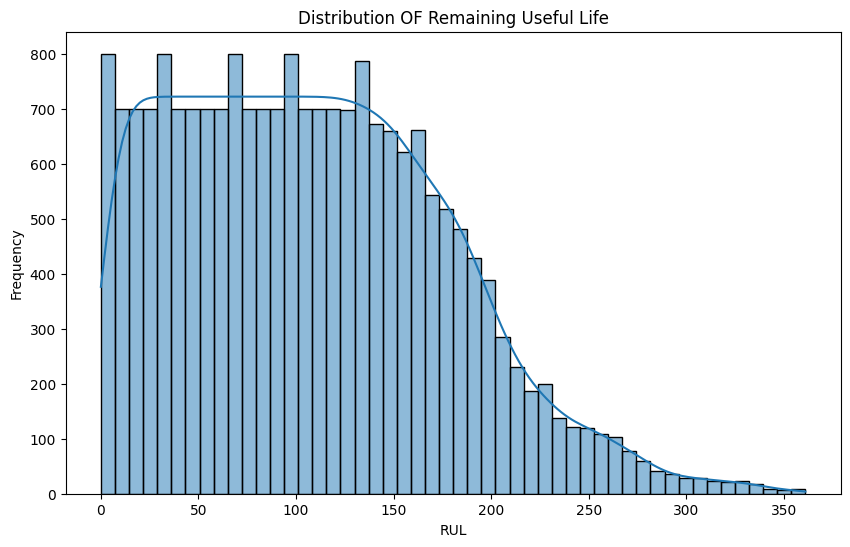

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(train_df['RUL'],bins=50,kde=True)
plt.title("Distribution OF Remaining Useful Life")
plt.xlabel("RUL")
plt.ylabel("Frequency")
plt.show()

In [ ]:
corr_matrix = train_df.corr(numeric_only=True)
rul_corr=corr_matrix["RUL"].sort_values(ascending=False)
print(rul_corr)

RUL             1.000000
sensors_12      0.671983
sensors_7       0.657223
sensors_21      0.635662
sensors_20      0.629428
max_cycle       0.363152
engine_id       0.078753
op_setting_2   -0.001948
op_setting_1   -0.003198
sensors_6      -0.128348
sensors_14     -0.306769
sensors_9      -0.390102
sensors_13     -0.562569
sensors_8      -0.563968
sensors_3      -0.584520
sensors_17     -0.606154
sensors_2      -0.606484
sensors_15     -0.642667
sensors_4      -0.678948
sensors_11     -0.696228
cycle          -0.736241
op_setting_3         NaN
sensors_1            NaN
sensors_5            NaN
sensors_10           NaN
sensors_16           NaN
sensors_18           NaN
sensors_19           NaN
Name: RUL, dtype: float64


In [ ]:
rul_corr.head(15)

,RUL
RUL,1.000000
sensors_12,0.671983
sensors_7,0.657223
sensors_21,0.635662
sensors_20,0.629428
max_cycle,0.363152
engine_id,0.078753
op_setting_2,-0.001948
op_setting_1,-0.003198
sensors_6,-0.128348


In [ ]:
rul_corr.tail(15)

,RUL
sensors_8,-0.563968
sensors_3,-0.584520
sensors_17,-0.606154
sensors_2,-0.606484
sensors_15,-0.642667
sensors_4,-0.678948
sensors_11,-0.696228
cycle,-0.736241
op_setting_3,NaN
sensors_1,NaN


In [ ]:
engine1=train_df[train_df['engine_id']==1]

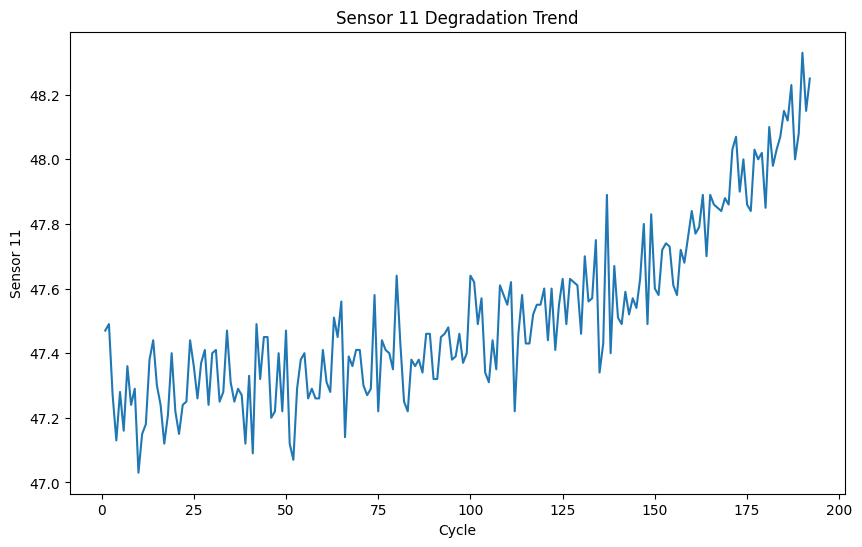

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(engine1['cycle'],engine1['sensors_11'])
plt.xlabel("Cycle")
plt.ylabel("Sensor 11")
plt.title("Sensor 11 Degradation Trend")
plt.show()

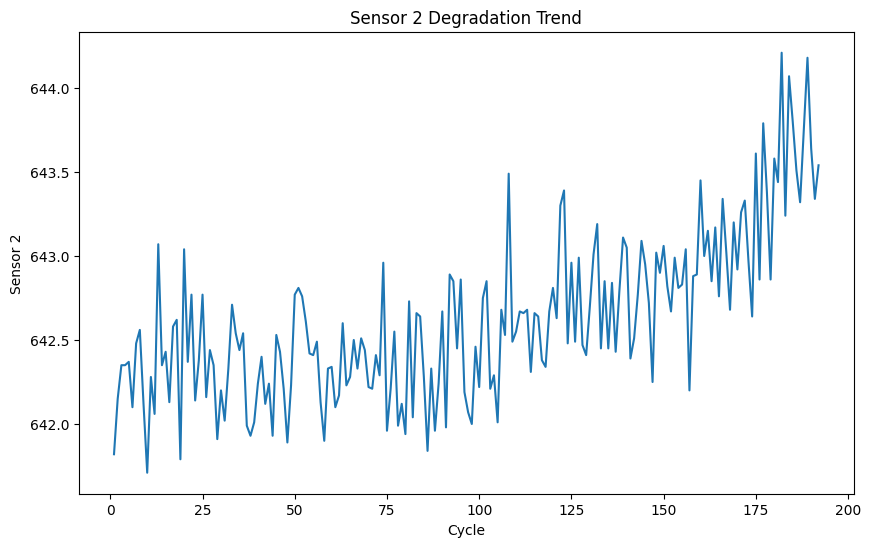

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(engine1['cycle'],engine1['sensors_2'])
plt.xlabel("Cycle")
plt.ylabel("Sensor 2")
plt.title("Sensor 2 Degradation Trend")
plt.show()

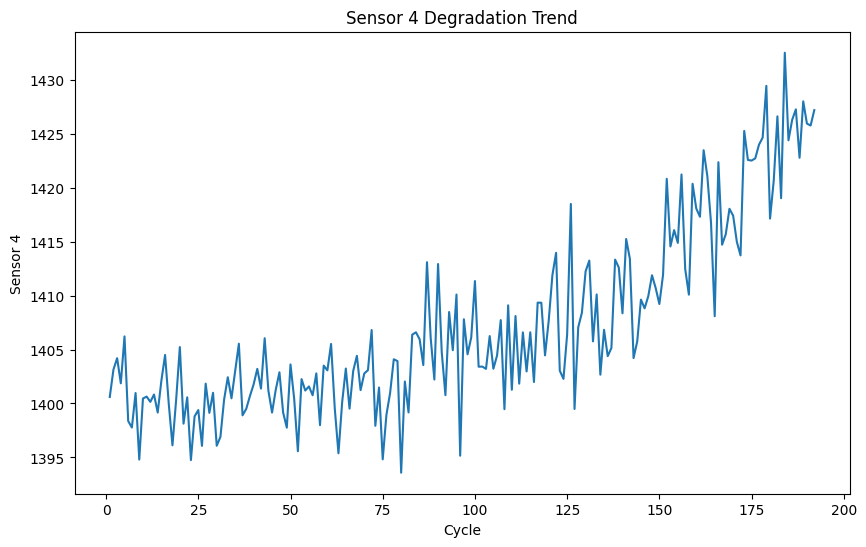

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(engine1['cycle'],engine1['sensors_4'])
plt.xlabel("Cycle")
plt.ylabel("Sensor 4")
plt.title("Sensor 4 Degradation Trend")
plt.show()

In [ ]:
train_df.std().sort_values()

,0
op_setting_3,0.000000e+00
sensors_18,0.000000e+00
sensors_19,0.000000e+00
sensors_16,1.556432e-14
sensors_10,4.660829e-13
sensors_5,3.394700e-12
sensors_1,6.537152e-11
op_setting_2,2.930621e-04
sensors_6,1.388985e-03
op_setting_1,2.187313e-03


In [ ]:
train_df.isnull().sum()

,0
engine_id,0
cycle,0
op_setting_1,0
op_setting_2,0
op_setting_3,0
sensors_1,0
sensors_2,0
sensors_3,0
sensors_4,0
sensors_5,0


In [ ]:
train_df[
[
'sensors_1',
'sensors_5',
'sensors_10',
'sensors_16',
'sensors_18',
'sensors_19'
]
].nunique()

,0
sensors_1,1
sensors_5,1
sensors_10,1
sensors_16,1
sensors_18,1
sensors_19,1


In [ ]:
drop_cols=['RUL','max_cycle','engine_id']

In [ ]:
x=train_df.drop(columns=drop_cols)
y=train_df['RUL']

In [ ]:
print(x.shape)
print(y.shape)

(20631, 25)
(20631,)


In [ ]:
constant_cols=[]
for cols in x.columns:
  if x[cols].nunique()==1:
    constant_cols.append(cols)
print(constant_cols)

['op_setting_3', 'sensors_1', 'sensors_5', 'sensors_10', 'sensors_16', 'sensors_18', 'sensors_19']


In [ ]:
x=x.drop(columns=constant_cols)

In [ ]:
x.shape

(20631, 18)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_val,y_train,y_val=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_trained_scaled=scaler.fit_transform(x_train)
x_val_scaled=scaler.transform(x_val)

In [ ]:
print(x_trained_scaled.shape)
print(x_val_scaled.shape)

(16504, 18)
(4127, 18)


In [ ]:
constant_cols

['op_setting_3',
 'sensors_1',
 'sensors_5',
 'sensors_10',
 'sensors_16',
 'sensors_18',
 'sensors_19']

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [ ]:
rf_model.fit(x_trained_scaled,y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [ ]:
y_pred = rf_model.predict(
    x_val_scaled
)

In [ ]:
for i in range(10):
    print(
        f"Actual: {y_val.iloc[i]:.0f}, "
        f"Predicted: {y_pred[i]:.0f}"
    )

Actual: 135, Predicted: 109
Actual: 2, Predicted: 9
Actual: 217, Predicted: 202
Actual: 0, Predicted: 2
Actual: 178, Predicted: 119
Actual: 70, Predicted: 115
Actual: 87, Predicted: 118
Actual: 87, Predicted: 81
Actual: 73, Predicted: 102
Actual: 77, Predicted: 143


In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
mae = mean_absolute_error(
    y_val,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_val,
        y_pred
    )
)

r2 = r2_score(
    y_val,
    y_pred
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 25.446052822873757
RMSE: 35.923474377347695
R²  : 0.7175412825208818


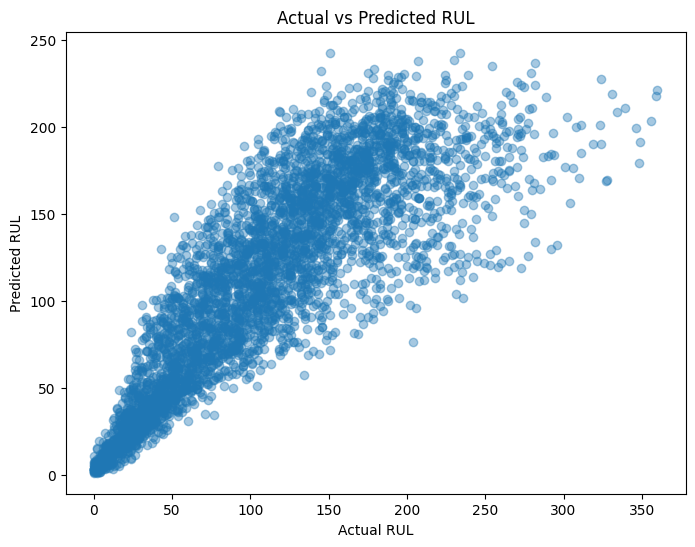

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_val,
    y_pred,
    alpha=0.4
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")

plt.title(
    "Actual vs Predicted RUL"
)

plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf_model.feature_importances_
})

In [ ]:
feature_importance = (
    feature_importance
    .sort_values(
        by='Importance',
        ascending=False
    )
)

In [ ]:
feature_importance.head(10)

,Feature,Importance
0,cycle,0.539977
10,sensors_11,0.141879
9,sensors_9,0.042552
5,sensors_4,0.039765
11,sensors_12,0.032108
13,sensors_14,0.024544
7,sensors_7,0.023563
14,sensors_15,0.021191
17,sensors_21,0.020496
3,sensors_2,0.019089


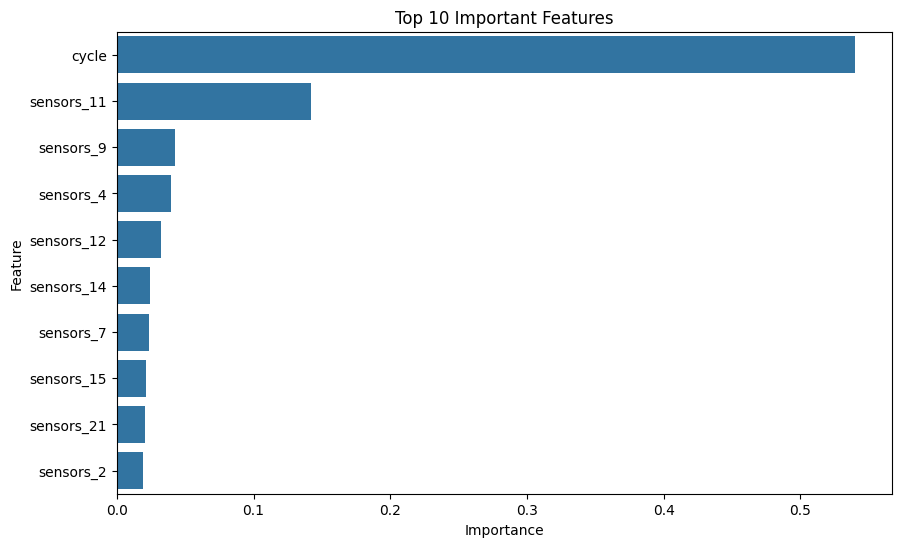

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title(
    "Top 10 Important Features"
)

plt.show()

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(
    x_trained_scaled,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb_model.predict(
    x_val_scaled
)

In [ ]:
mae_xgb = mean_absolute_error(
    y_val,
    y_pred_xgb
)

rmse_xgb = np.sqrt(
    mean_squared_error(
        y_val,
        y_pred_xgb
    )
)

r2_xgb = r2_score(
    y_val,
    y_pred_xgb
)

print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R²  :", r2_xgb)

MAE : 25.37499237060547
RMSE: 35.84290539545448
R²  : 0.7188068628311157


In [ ]:
import joblib

joblib.dump(
    xgb_model,
    "engine_rul_model.pkl"
)

['engine_rul_model.pkl']

In [ ]:
joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

In [ ]:
print(x.columns.tolist())


['cycle', 'op_setting_1', 'op_setting_2', 'sensors_2', 'sensors_3', 'sensors_4', 'sensors_6', 'sensors_7', 'sensors_8', 'sensors_9', 'sensors_11', 'sensors_12', 'sensors_13', 'sensors_14', 'sensors_15', 'sensors_17', 'sensors_20', 'sensors_21']


In [92]:
print(type(rf_model))
print(type(xgb_model))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>
<class 'xgboost.sklearn.XGBRegressor'>
